In [1]:
import scanpy as sc

In [3]:
adata = sc.read_h5ad("/Users/kylekimler/Projects/GCA/meta_datasets/20250717_CxG_upload_checkpoint.h5ad")
adata

AnnData object with n_obs × n_vars = 1497230 × 36353
    obs: 'sample_id', 'author_cell_type', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_platfor

In [5]:
for celltype in adata.obs['cell_type_atlas'].unique():
    print(celltype)

CD4 T Cells
CD8 T Cells
ILC1
M1
Memory B Cells
Naive B Cells
NK Cells
Plasma Cells
cDC2
ILC3
Germinal Center B Cells (GC)
Unconventional T Cells
Follicular Dendritic Cells
Fibroblasts Submucosal  (S3)
Mast Cells
Enteroendocrine Cells (EEC)
Epithelial Stem Cells (LGR5+)
Enterocytes
Endothelial
Pericytes
Colonocytes
Fibroblasts Subepithelial (S2)
Tuft Cells
Paneth Cells
Fibroblasts Subserosal
Fibroblasts Lamina propria (S1)
Glia
Myofibroblasts
Goblet Cells
Transiently Amplifying Cells (TA)
Mature goblet cells
Fibroblastic reticular cells


## Searching for rare cell types yet undescribed in scRNA data

### Subset to relevant parent celltype

In [6]:
adata_sub = adata[adata.obs['cell_type_atlas'] == 'Enteroendocrine Cells (EEC)'].copy()
adata_sub

AnnData object with n_obs × n_vars = 4481 × 36353
    obs: 'sample_id', 'author_cell_type', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term', 'sex_ontology_term_id', 'age_at_biopsy', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_embedding', 'sequencing_platform',

### recalculate UMAP within parent celltype

In [7]:
sc.pp.pca(adata_sub)
sc.pp.neighbors(adata_sub)
sc.tl.umap(adata_sub)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### show putative marker genes on resulting subset UMAP

In [9]:
adata.var

,gene_id,gene_symbol,mt,ribo,hb,n_cells,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,hvg_marker,feature_is_filtered
ENSG00000000003,ENSG00000000003,TSPAN6,False,False,False,130826,195140,0.094287,0.090103,94.224985,318599,12.671692,False,0.076050,1.038674,-1.111607,10,False,False,False
ENSG00000000005,ENSG00000000005,TNMD,False,False,False,3135,4878,0.001594,0.001593,99.855639,5387,8.591930,False,0.001454,0.667250,-0.527142,4,False,False,False
ENSG00000000419,ENSG00000000419,DPM1,False,False,False,254820,329289,0.129758,0.122003,90.254951,438457,12.991019,False,0.150211,1.092318,inf,6,False,False,False
ENSG00000000457,ENSG00000000457,SCYL3,False,False,False,136455,175516,0.060628,0.058861,94.805742,204864,12.230107,False,0.063990,1.189661,0.017007,8,False,False,False
ENSG00000000460,ENSG00000000460,C1orf112,False,False,False,57454,70285,0.024555,0.024258,97.919971,82971,11.326258,False,0.025647,1.210943,-0.018293,12,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288380,ENSG00000288380,CRIPAK,False,False,False,16897,20886,0.006547,0.006525,99.381895,22122,10.004373,False,0.008141,0.529624,-0.047372,4,False,False,False
ENSG00000288398,ENSG00000288398,AL109627.1,False,False,False,2644,3151,0.000945,0.000944,99.906749,3193,8.069029,False,0.001483,0.521270,0.030542,12,False,False,False
ENSG00000288436,ENSG00000288436,AC024558.2,False,False,False,1438,1631,0.000532,0.000532,99.951732,1799,7.495542,False,0.001226,0.269041,-0.007030,5,False,False,False
ENSG00000288459,ENSG00000288459,AL512357.2,False,False,False,2888,3349,0.001025,0.001024,99.900889,3462,8.149891,False,0.001375,0.174228,0.044378,4,False,False,False


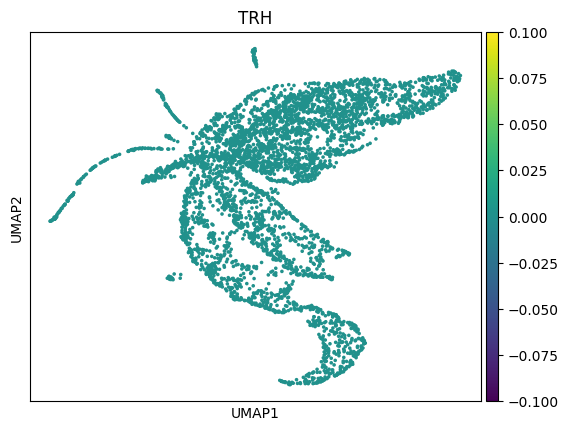

In [11]:
sc.pl.umap(adata_sub, color=['TRH'], gene_symbols='gene_symbol')


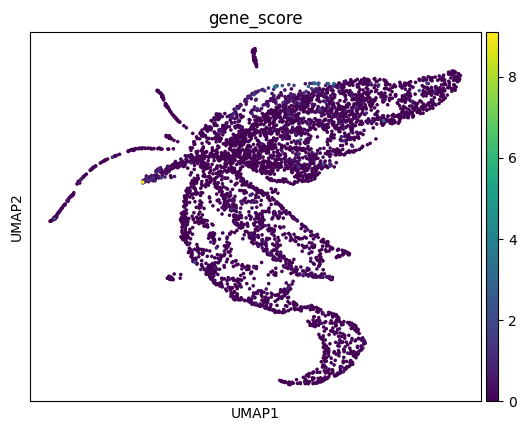

In [18]:
genes = ['SYT10','KLHL4','DGKI','CDH10','NCAM2','IL1RAP','GHR','CDH4','SRRM4','CNTN4']
adata_sub.obs['gene_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(genes)].X.mean(axis=1)
sc.pl.umap(adata_sub, color='gene_score')


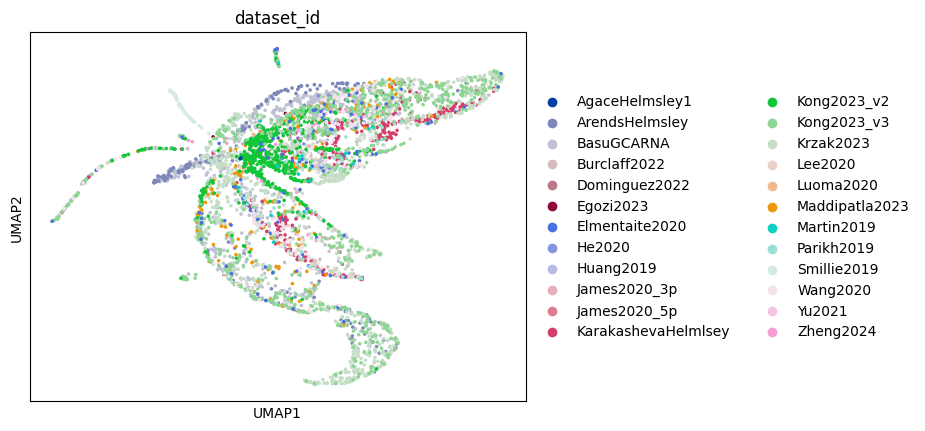

In [20]:
sc.pl.umap(adata_sub, color=['dataset_id'])


In [16]:
adata_sub.obs['tissue_ontology_term'].value_counts()

tissue_ontology_term
ileal mucosa            2435
ileum                    702
colonic epithelium       450
ileal epithelium         378
colon                    186
epithelium of rectum      82
mucosa of rectum          36
transverse colon          30
jejunal epithelium        30
duodenal epithelium       29
colonic mucosa            27
sigmoid colon             25
small intestine           22
duodenal mucosa           12
jejunum                   10
caecum                     9
rectum                     5
descending colon           4
cecum mucosa               3
duodenum                   2
terminal ileum             2
ascending colon            1
vermiform appendix         1
Name: count, dtype: int64

### Secretory - bicarbonate producers

In [21]:
for celltype in adata.obs['cell_type_atlas'].unique():
    print(celltype)

CD4 T Cells
CD8 T Cells
ILC1
M1
Memory B Cells
Naive B Cells
NK Cells
Plasma Cells
cDC2
ILC3
Germinal Center B Cells (GC)
Unconventional T Cells
Follicular Dendritic Cells
Fibroblasts Submucosal  (S3)
Mast Cells
Enteroendocrine Cells (EEC)
Epithelial Stem Cells (LGR5+)
Enterocytes
Endothelial
Pericytes
Colonocytes
Fibroblasts Subepithelial (S2)
Tuft Cells
Paneth Cells
Fibroblasts Subserosal
Fibroblasts Lamina propria (S1)
Glia
Myofibroblasts
Goblet Cells
Transiently Amplifying Cells (TA)
Mature goblet cells
Fibroblastic reticular cells


In [23]:
adata_sub = adata[adata.obs['cell_type_atlas'].isin(['Goblet Cells', 'Mature goblet cells', 'Enterocytes', 'Colonocytes', 'Paneth Cells'])].copy()

sc.pp.pca(adata_sub); sc.pp.neighbors(adata_sub); sc.tl.umap(adata_sub)

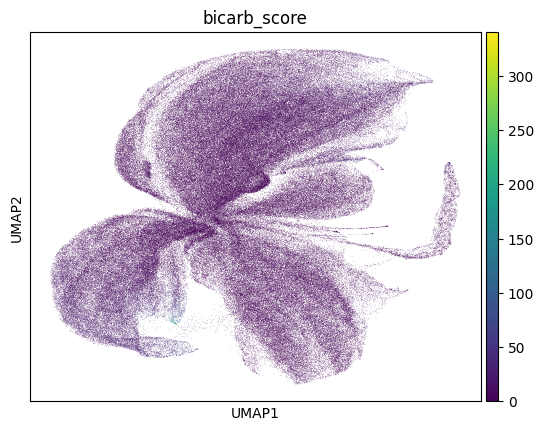

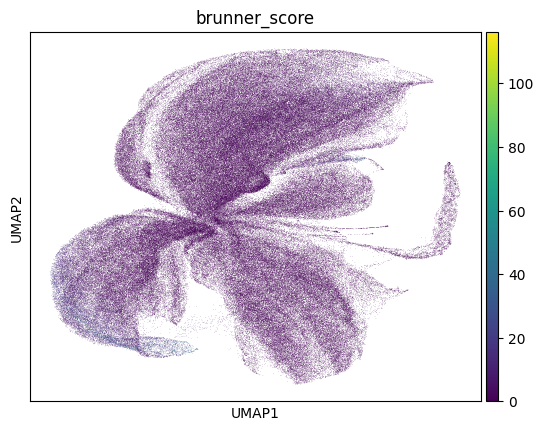

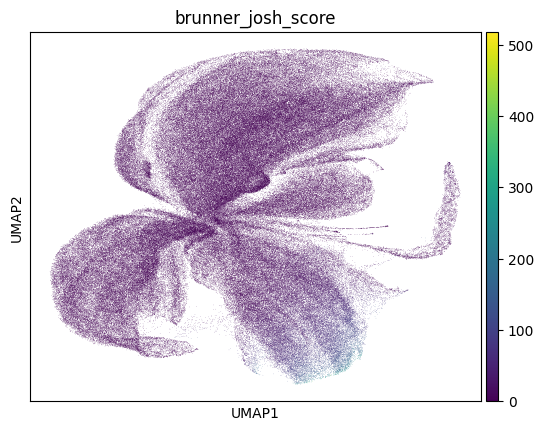

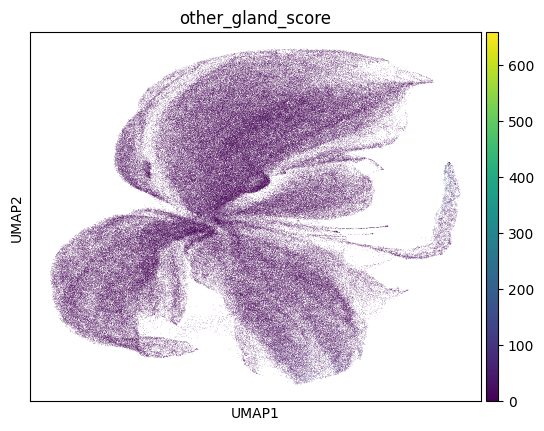

In [41]:
genes = ['SLC26A3', 'SLC4A4', 'SLC4A10', 'CFTR', 'CA2', 'CA4', 'CA12', 'GUCA2A', 'GUCA2B', 'BEST4', 'OTOP2', 'PIGR', 'MUC6']
brunner_genes = ['MUC6', 'TFF2', 'SLC26A3', 'CA12', 'AQP5']
brunner_genes_josh = ['MUC6','PGC','TFF2','HDAC9','TFF3','AQP5']
other_gland_genes = ['MUC5AC','ANXA10','LYZ','REG4','CAPN8']


adata_sub.obs['bicarb_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(genes)].X.mean(axis=1).A1

adata_sub.obs['brunner_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(brunner_genes)].X.mean(axis=1).A1

adata_sub.obs['brunner_josh_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(brunner_genes_josh)].X.mean(axis=1).A1
adata_sub.obs['other_gland_score'] = adata_sub[:, adata_sub.var['gene_symbol'].isin(other_gland_genes)].X.mean(axis=1).A1

sc.pl.umap(adata_sub, color='bicarb_score')

sc.pl.umap(adata_sub, color='brunner_score')

sc.pl.umap(adata_sub, color='brunner_josh_score')

sc.pl.umap(adata_sub, color='other_gland_score')

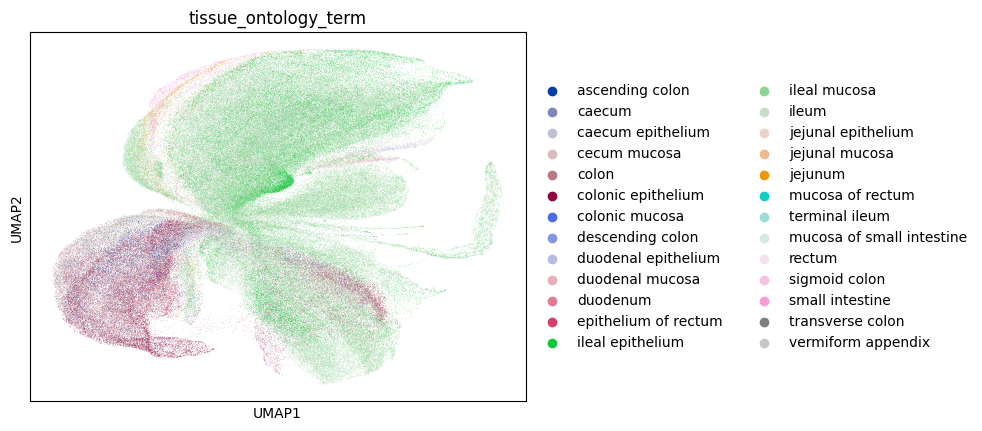

In [26]:
sc.pl.umap(adata_sub, color='tissue_ontology_term')

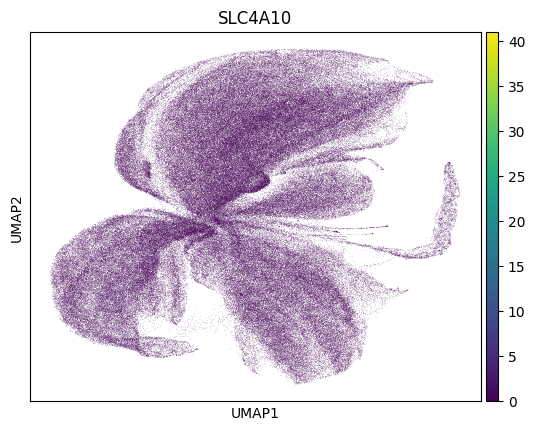

In [27]:
sc.pl.umap(adata_sub, color=['SLC4A10'], gene_symbols='gene_symbol')



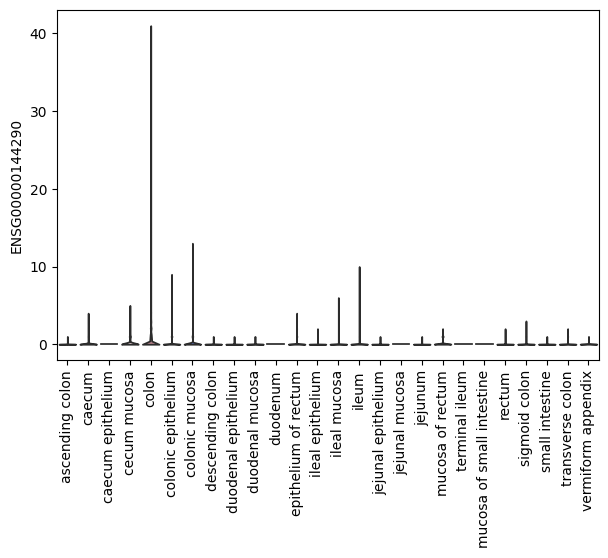

In [37]:
gene = adata_sub.var_names[adata_sub.var['gene_symbol'] == 'SLC4A10'][0]
sc.pl.violin(adata_sub, keys=[gene], groupby='tissue_ontology_term', stripplot=False, rotation=90)

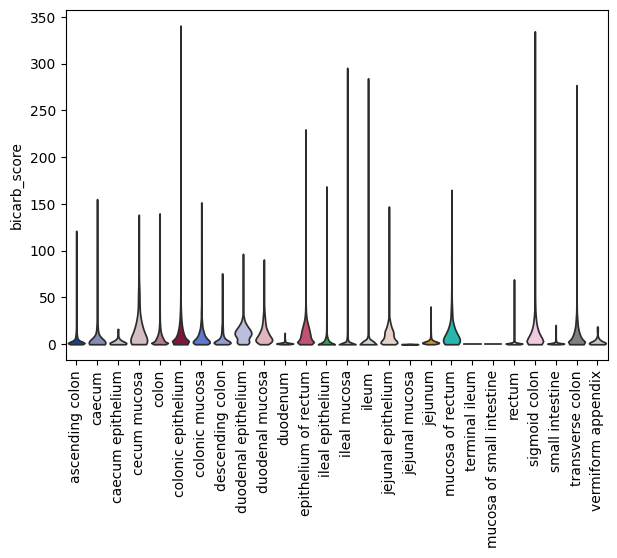

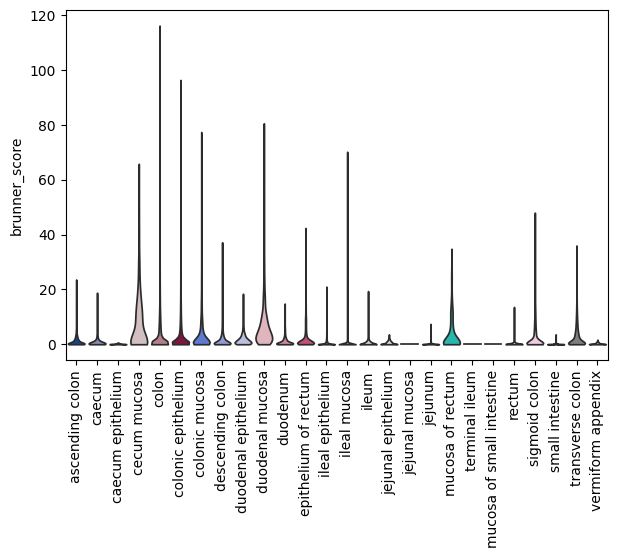

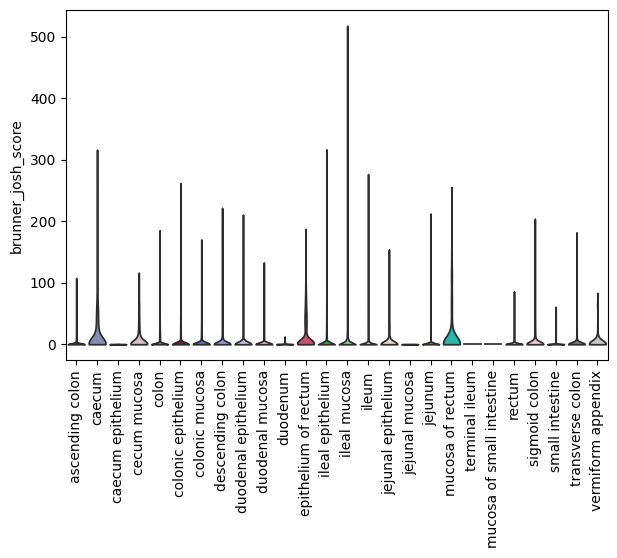

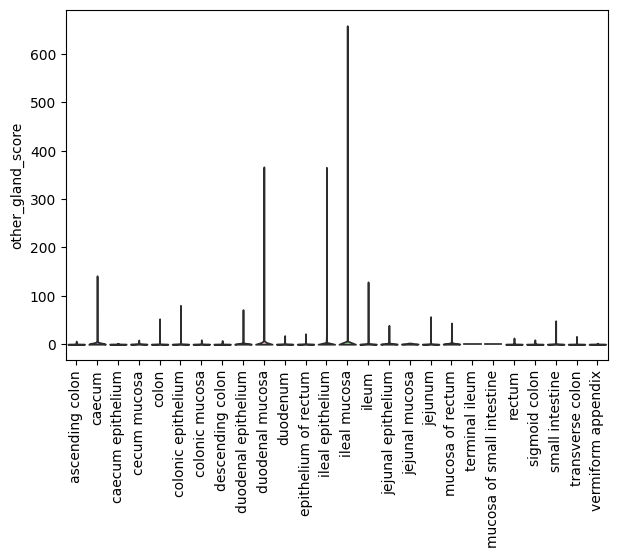

In [43]:
sc.pl.violin(adata_sub, keys=['bicarb_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['brunner_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['brunner_josh_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

sc.pl.violin(adata_sub, keys=['other_gland_score'], groupby='tissue_ontology_term', stripplot=False, rotation=90)

In [45]:
adata.obs[['tissue_ontology_term','radial_tissue_term']].drop_duplicates()

,tissue_ontology_term,radial_tissue_term
0,ileum,EPI_LP_MUSC
344,gastrointestinal system mesentery,EPI_LP_MUSC
743,caecum,EPI_LP_MUSC
813,duodenum,EPI_LP_MUSC
2163,transverse colon,EPI_LP_MUSC
2229,sigmoid colon,EPI_LP_MUSC
2280,ileal mucosa,EPI_LP
4097,mucosa of small intestine,EPI_LP
4530,colon,WM
9931,ileum,WM
